In [ ]:
import h5py
import glob
import os
import numpy as np
import pandas as pd
import scipy as sp
import seaborn as sns
import cooler
import umap
from itertools import cycle, islice
import anndata
import xarray

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import ticker
from matplotlib.colors import LogNorm
from matplotlib import cm as cm
import cooltools.lib.plotting

from scipy import ndimage as nd
from scipy.stats import pearsonr
from scipy.signal import find_peaks
from scipy.signal import peak_prominences

from sklearn.decomposition import PCA
from statsmodels.sandbox.stats.multicomp import multipletests as FDR
from concurrent.futures import ProcessPoolExecutor, as_completed

In [2]:
def compute_domain_size(i):
    global res, sc_border
    tmp = sc_border.raw.X[i]
    tmp = np.repeat(tmp.indices, tmp.data).reshape((-1, 2))
    return (tmp[:, 1] - tmp[:, 0]).sum() * res

In [3]:
celltype_colors = {'vCM' : "#b94656",
    'aCM' : "#b95c38",
    'Fibroblast' : "#c0a13b",
    'SM' : "#71893b",
    'Pericyte' : "#6dbc5f",
    'Epicardial' : "#45c097",
    'Endocardial' : "#628ed6",
    'Endothelial' : "#6a70d7",
    'Neuronal' : "#5a3687",
    'Myeloid' : "#c074cc",
    'Lymphoid' : "#d16bad",
    'Adipocyte' : "#aa3d71"}

In [4]:
chrom_size_path = '/projects/ps-renlab2/y2xie/projects/genome_ref/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)

In [5]:
### Final retention:
fmeta = pd.read_csv("integration/All_data.int.csv", index_col = 0)
fmeta = fmeta.loc[(fmeta['orig.ident'] == 'DHC') & (fmeta['predicted.score'] > 0.9)]
print(fmeta.shape)
np.unique(fmeta['condition'], return_counts=True)

/tmp/ipykernel_979315/2392747024.py:2: DtypeWarning: Columns (4,5,6,7,54,55,58,59,60,62,63,64,66,74,75,78,79,80,81,82,83,84,88,89,90,91,92,93,94,95,96,97,98,99,101,103,106,117,126,128,131,134,144,146) have mixed types. Specify dtype option on import or set low_memory=False.
  fmeta = pd.read_csv("integration/All_data.int.csv", index_col = 0)


(63090, 149)


(array(['CONTROL', 'HF'], dtype=object), array([20195, 42895]))

## Calling domains on donor-pseudobulk level

In [175]:
### Donor levels
### remove X too due to imbalanced F/M donor numbers
bulk_border = anndata.read_h5ad(f'/projects/ps-renlab2/y2xie/projects/77.LC/87.FNIH_DHC_IGM_240925/impute/25K/cool/DONOR/domain.boundary.h5ad')
bulk_border = bulk_border[:, ~bulk_border.var['chrom'].isin(['chrX','chrY','chrM','chrL'])].copy()
bulk_border.X

<359x115009 sparse matrix of type '<class 'numpy.float32'>'
	with 1466873 stored elements in Compressed Sparse Row format>

In [178]:
fmeta['tmp'] = fmeta['Patient.ID'] + "_" + fmeta['predicted.id'] + '_' + fmeta['condition']
res = 25000
domain_size, cell_list, cell_number_list = [], [], []
ncpu = 8
for i,cell in enumerate(bulk_border.obs.index):
    cell_list.append(cell)
    cell_number_list.append(fmeta.loc[fmeta['tmp'] == cell].shape[0])
    tmp = bulk_border.X[i]
    tmp = np.repeat(tmp.indices, tmp.data.astype('int64')).reshape((-1, 2))
    domain_size.append((tmp[:, 1] - tmp[:, 0]).sum() * res)

domain_size = pd.DataFrame(domain_size, index=cell_list, columns = ['domain_coverage'])
domain_size['boundary_count'] = bulk_border.X.getnnz(axis=1)
domain_size['domain_count'] = bulk_border.X.sum(axis=1).A1 / 2
domain_size['domain_size'] = domain_size['domain_coverage'] / domain_size['domain_count']
domain_size['cell_number'] = cell_number_list
domain_size[['donor', 'celltype', 'condition']] = domain_size.index.to_series().str.split('_', expand=True)

domain_size

,domain_coverage,boundary_count,domain_count,domain_size,cell_number,donor,celltype,condition
D35_aCM_CONTROL,2704925000,6272,5152.0,5.250243e+05,245,D35,aCM,CONTROL
D35_Adipocyte_CONTROL,243100000,14,10.0,2.431000e+07,4,D35,Adipocyte,CONTROL
D35_Endocardial_CONTROL,2868300000,881,802.0,3.576434e+06,15,D35,Endocardial,CONTROL
D35_Endothelial_CONTROL,2716775000,6327,5192.0,5.232617e+05,448,D35,Endothelial,CONTROL
D35_Epicardial_CONTROL,2866925000,956,859.0,3.337515e+06,15,D35,Epicardial,CONTROL
...,...,...,...,...,...,...,...,...
DTX119_Myeloid_HF,2703125000,6989,5757.0,4.695371e+05,324,DTX119,Myeloid,HF
DTX119_Neuronal_HF,2863775000,1395,1269.0,2.256718e+06,22,DTX119,Neuronal,HF
DTX119_Pericyte_HF,2784300000,4973,4276.0,6.511459e+05,102,DTX119,Pericyte,HF
DTX119_SM_HF,2849125000,2192,1954.0,1.458099e+06,37,DTX119,SM,HF


/tmp/ipykernel_2526597/3901825788.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(corder, rotation=90)


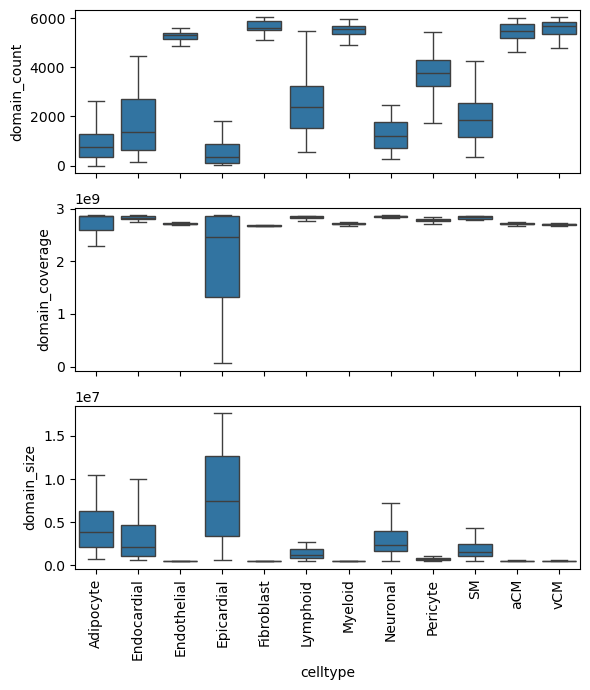

In [179]:
fig, axes = plt.subplots(3, 1, figsize=(6,7), sharex='all')

corder = np.unique(fmeta['predicted.id'])

ax = axes[0]
sns.boxplot(data=domain_size, x='celltype', y='domain_count', order=corder, showfliers=False, ax=ax)
ax = axes[1]
sns.boxplot(data=domain_size, x='celltype', y='domain_coverage', order=corder, showfliers=False, ax=ax)
ax = axes[2]
sns.boxplot(data=domain_size, x='celltype', y='domain_size', order=corder, showfliers=False, ax=ax)

ax.set_xticklabels(corder, rotation=90)
plt.tight_layout()

In [343]:
domain_size.to_csv("FNIH_Heart_DHC_Donor_celltype_disease_boundary_summary.csv")

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 43 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'C', 'D', 'F', 'K', 'N', 'P', 'S', 'V', 'a', 'b', 'comma', 'd', 'e', 'eight', 'equal', 'five', 'four', 'g', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'percent', 'period', 'r', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'x', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 8, 11, 12, 15, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 32, 38, 39, 41, 46, 49, 51, 54, 57, 68, 69, 71, 72, 74, 76, 79, 80, 81, 82, 85, 87, 88, 89, 91]
INFO:fo

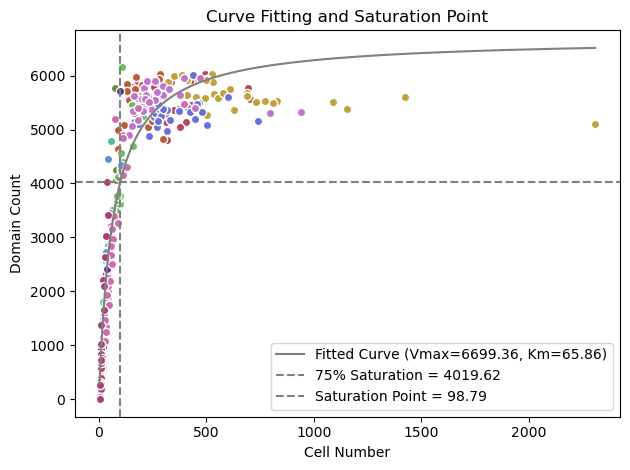

In [199]:
### Find minimal cell number required to saturate number of boundary
from scipy.optimize import curve_fit

def michaelis_menten(x, vmax, km):
    return vmax * x / (km + x)

x_data = np.array(domain_size['cell_number']) 
y_data = np.array(domain_size['domain_count']) 
params, _ = curve_fit(michaelis_menten, x_data, y_data, p0=[np.max(y_data), np.median(x_data)])
vmax, km = params
saturation_threshold = 0.6 * vmax
saturation_point = km * (saturation_threshold / (vmax - saturation_threshold))

x_fit = np.linspace(min(x_data), max(x_data), 1000)
y_fit = michaelis_menten(x_fit, vmax, km)

for group, color in celltype_colors.items():
    subset = domain_size[domain_size['celltype'] == group]
    plt.scatter(np.array(subset['cell_number']) , np.array(subset['domain_count']), edgecolors = "white", c=[color])

plt.plot(x_fit, y_fit, color="grey", label=f"Fitted Curve (Vmax={vmax:.2f}, Km={km:.2f})")
plt.axhline(saturation_threshold, color="grey", linestyle="--", label=f"60% Saturation = {saturation_threshold:.2f}")
plt.axvline(saturation_point, color="grey", linestyle="--", label=f"Saturation Point = {saturation_point:.2f}")
plt.xlabel("Cell Number")
plt.ylabel("Domain Count")
plt.legend()
plt.title("Curve Fitting and Saturation Point")
plt.tight_layout()

plt.savefig(f'plot/FIG_domain_count_by_donor.pdf', transparent = True)

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 42 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'C', 'F', 'K', 'N', 'P', 'S', 'V', 'a', 'b', 'comma', 'd', 'e', 'eight', 'equal', 'five', 'four', 'g', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'percent', 'period', 'r', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'x', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 8, 11, 12, 15, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 32, 38, 41, 46, 49, 51, 54, 57, 68, 69, 71, 72, 74, 76, 79, 80, 81, 82, 85, 87, 88, 89, 91]
INFO:fontTools.s

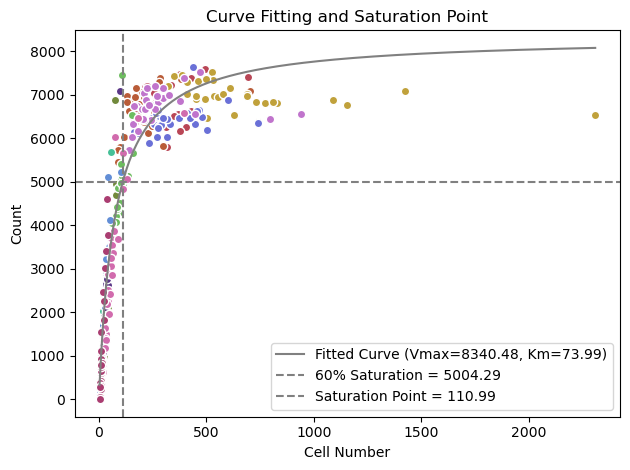

In [200]:
y_data = np.array(domain_size['boundary_count']) 

params, _ = curve_fit(michaelis_menten, x_data, y_data, p0=[np.max(y_data), np.median(x_data)])
vmax, km = params
saturation_threshold = 0.6 * vmax
saturation_point = km * (saturation_threshold / (vmax - saturation_threshold))

x_fit = np.linspace(min(x_data), max(x_data), 1000)
y_fit = michaelis_menten(x_fit, vmax, km)

for group, color in celltype_colors.items():
    subset = domain_size[domain_size['celltype'] == group]
    plt.scatter(np.array(subset['cell_number']) , np.array(subset['boundary_count']), edgecolors = "white", c=[color])

plt.plot(x_fit, y_fit, color="grey", label=f"Fitted Curve (Vmax={vmax:.2f}, Km={km:.2f})")
plt.axhline(saturation_threshold, color="grey", linestyle="--", label=f"60% Saturation = {saturation_threshold:.2f}")
plt.axvline(saturation_point, color="grey", linestyle="--", label=f"Saturation Point = {saturation_point:.2f}")
plt.xlabel("Cell Number")
plt.ylabel("Count")
plt.legend()
plt.title("Curve Fitting and Saturation Point")
plt.tight_layout()

plt.savefig(f'plot/FIG_boundary_count_by_donor.pdf', transparent = True)

In [201]:
print(np.unique(domain_size['cell_number'] >= saturation_point, return_counts = True))

print(np.unique(domain_size['cell_number'] >= 100, return_counts = True)) 
### also group cells to around 100 cells / group for pseudo cells

(array([False,  True]), array([203, 156]))
(array([False,  True]), array([195, 164]))


In [202]:
tmp = domain_size.loc[domain_size['cell_number'] >= saturation_point]
print(np.unique(tmp['donor'], return_counts = True))
print(np.unique(tmp['celltype'], return_counts = True))
print(np.unique(tmp['celltype'] + "_" + tmp['condition'], return_counts = True))

(array(['D35', 'D36', 'D37', 'D38', 'D40', 'D47', 'D51', 'D52', 'D53',
       'D55', 'DTX017', 'DTX027', 'DTX031', 'DTX037', 'DTX060', 'DTX062',
       'DTX065', 'DTX066', 'DTX077', 'DTX081', 'DTX087', 'DTX088',
       'DTX089', 'DTX091', 'DTX093', 'DTX096', 'DTX097', 'DTX105',
       'DTX114', 'DTX119'], dtype=object), array([6, 6, 5, 5, 5, 5, 6, 5, 5, 5, 5, 4, 6, 5, 5, 7, 5, 6, 6, 5, 5, 5,
       6, 4, 3, 5, 5, 5, 6, 5]))
(array(['Endothelial', 'Fibroblast', 'Lymphoid', 'Myeloid', 'Pericyte',
       'aCM', 'vCM'], dtype=object), array([30, 30,  4, 30,  6, 27, 29]))
(array(['Endothelial_CONTROL', 'Endothelial_HF', 'Fibroblast_CONTROL',
       'Fibroblast_HF', 'Lymphoid_CONTROL', 'Lymphoid_HF',
       'Myeloid_CONTROL', 'Myeloid_HF', 'Pericyte_CONTROL', 'Pericyte_HF',
       'aCM_CONTROL', 'aCM_HF', 'vCM_CONTROL', 'vCM_HF'], dtype=object), array([10, 20, 10, 20,  1,  3, 10, 20,  2,  4, 10, 17, 10, 19]))


In [203]:
### Retain valid group (and donors):
validc = ['Endothelial', 'Fibroblast', 'Myeloid', 'aCM', 'vCM']
fdomain_size = domain_size.loc[(domain_size['celltype'].isin(validc)) & (domain_size['cell_number'] >= saturation_point)]

# Adding ICM/NICM information
donor_info = pd.read_csv("../../81.FNIH_DPT_IGM_240827/reference/CAREHF_FNIH_donor.simple.info", sep = '\t', index_col=1)
fdomain_size['HF'] = donor_info.loc[fdomain_size['donor']]['HF'].values
fdomain_size.to_csv("FNIH_Heart_DHC_Donor_celltype_disease_boundary_filtered_summary.csv")

/tmp/ipykernel_2526597/4082701433.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fdomain_size['HF'] = donor_info.loc[fdomain_size['donor']]['HF'].values


In [204]:
### how mnay non-zero boundary?
bulk_border = bulk_border[fdomain_size.index, :]

rows, cols = bulk_border.X.nonzero()
nonzero_by_row = {}
for r, c in zip(rows, cols):
    nonzero_by_row.setdefault(r, []).append(c)
    
bulk_border.var['range'] = bulk_border.var['chrom'].astype(str) + ":" + bulk_border.var['start'].astype(str) + "-" + bulk_border.var['end'].astype(str)
allbound = []
for i, f in nonzero_by_row.items():
    allbound.append(np.array(bulk_border.var['range'][f]))
    
allbound = np.unique([item for sublist in allbound for item in sublist])
len(allbound)

/tmp/ipykernel_2526597/3412007964.py:9: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  bulk_border.var['range'] = bulk_border.var['chrom'].astype(str) + ":" + bulk_border.var['start'].astype(str) + "-" + bulk_border.var['end'].astype(str)
/tmp/ipykernel_2526597/3412007964.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  allbound.append(np.array(bulk_border.var['range'][f]))


93078

In [205]:
bulk_border.obs['celltype'] = fdomain_size.loc[bulk_border.obs_names]['celltype']
bound_count_ct = []
for xx in np.unique(fdomain_size['celltype']):
    bound_count_ct.append(bulk_border.X[bulk_border.obs['celltype']==xx].getnnz(axis=0))

bound_count_ct = pd.DataFrame(bound_count_ct, index=np.unique(fdomain_size['celltype']), 
                              columns=bulk_border.var['chrom'].astype(str) + '_' + (bulk_border.var['start'] // res).astype(str))
cell_count_ct = bulk_border.obs['celltype'].value_counts()

bound_count_ct.to_hdf(f'../impute/25K/cool/DONOR/FNIH_Heart_DHC_Donor_celltype_boundcount.hdf', key='data')
cell_count_ct.to_csv(f'../impute/25K/cool/DONOR/FNIH_Heart_DHC_Donor_celltype_cellcount.csv')

bound_prob_ct = (np.array(bound_count_ct) / np.array(cell_count_ct)[:, None]).T 

In [206]:
### insulation score
ins_count = xarray.open_dataset('/projects/ps-renlab2/y2xie/projects/77.LC/87.FNIH_DHC_IGM_240925/impute/25K/cool/DONOR/domain.insulation.nc')
bulk_ins = ins_count['__xarray_dataarray_variable__'].to_pandas().T
bin_name = ins_count['bin_chrom'].to_pandas() + '-' + ins_count['bin_start'].to_pandas().astype(str) + '-' + ins_count['bin_end'].to_pandas().astype(str)
bulk_ins.index = bin_name
# bulk_ins.to_csv("/projects/ps-renlab2/y2xie/projects/77.LC/87.FNIH_DHC_IGM_240925/impute/25K/cool/DONOR/FNIH_Heart_DHC_DONOR_celltype_disease_insulation.csv")
bulk_ins

cell,D35_aCM_CONTROL,D35_Adipocyte_CONTROL,D35_Endocardial_CONTROL,D35_Endothelial_CONTROL,D35_Epicardial_CONTROL,D35_Fibroblast_CONTROL,D35_Lymphoid_CONTROL,D35_Myeloid_CONTROL,D35_Neuronal_CONTROL,D35_Pericyte_CONTROL,...,DTX119_Endocardial_HF,DTX119_Endothelial_HF,DTX119_Epicardial_HF,DTX119_Fibroblast_HF,DTX119_Lymphoid_HF,DTX119_Myeloid_HF,DTX119_Neuronal_HF,DTX119_Pericyte_HF,DTX119_SM_HF,DTX119_vCM_HF
chr1-0-25000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
chr1-25000-50000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chr1-50000-75000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chr1-75000-100000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chr1-100000-125000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrY-57125000-57150000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chrY-57150000-57175000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chrY-57175000-57200000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chrY-57200000-57225000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [207]:
binall = ins_count[['bin_chrom', 'bin_start', 'bin_end']].to_pandas()
binall.columns = binall.columns.str.split('_').str[1]
binall.index = binall['chrom'] + '_' + (binall['start'] // res).astype(str)
binall.head()

,chrom,start,end
chr1_0,chr1,0,25000
chr1_1,chr1,25000,50000
chr1_2,chr1,50000,75000
chr1_3,chr1,75000,100000
chr1_4,chr1,100000,125000


### Filter bad bins for downstream analysis

<Axes: xlabel='rowsum', ylabel='Count'>

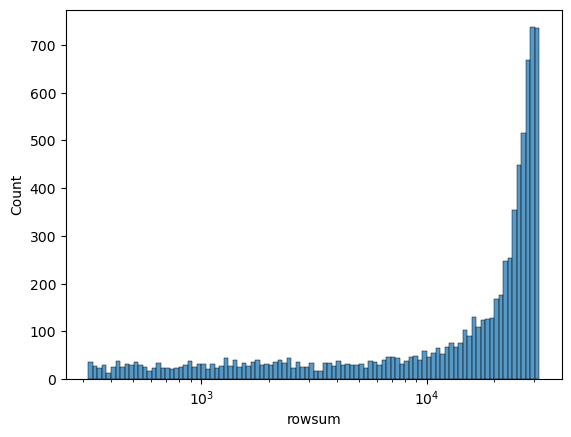

In [87]:
### generate domain blacklist (low counts)
cool = cooler.Cooler('../04.matrices/FNIH_heart_dhc.mcool::/resolutions/25000')

data = cool.pixels()[:]
data = sp.sparse.csr_matrix((data['count'], (data['bin1_id'], data['bin2_id'])), shape=cool.shape)

bin_df = cool.bins()[:]
bin_df['rowsum'] = data.sum(axis=0).A1

sns.histplot(bin_df.loc[bin_df['rowsum']>0, 'rowsum'], bins=100, log_scale=10, binrange=(2.5,4.5))
bin_df.loc[bin_df['rowsum']<3e3, ['chrom', 'start', 'end']].to_csv('../impute/25K/domain/hg38.main.rowsum3000.25kb.bed', sep='\t', header=False, index=False)

In [210]:
### filter bad bins
binall = binall.loc[binall['chrom'].isin(chrom_sizes[:22].index)]
binall['bin'] = binall['chrom'] + "-" + binall['start'].astype(str) + "-" + binall['end'].astype(str)
bulk_ins = bulk_ins.loc[binall['bin']]
print(bulk_ins.shape)

(115009, 359)


/tmp/ipykernel_2526597/4009221346.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  binall['bin'] = binall['chrom'] + "-" + binall['start'].astype(str) + "-" + binall['end'].astype(str)


In [213]:
### After filering
bound_count_ct = bound_count_ct[binall.index]
bound_prob_ct = (np.array(bound_count_ct) / np.array(cell_count_ct)[:, None]).T 
pd.DataFrame(bound_prob_ct, columns=bound_count_ct.index, index = bound_count_ct.columns).to_csv("../impute/25K/cool/DONOR/FNIH_Heart_DHC_Donor_celltype_boundprob.csv")

bound_prob_ct.shape

(115009, 5)

In [164]:
### Calculate boundary strengh for all donors: we have too few donor number for fihser test
boundstrength = pd.DataFrame(0, index=bulk_ins.index, columns=bulk_ins.columns, dtype = float)

for xx in bulk_ins.columns:
    for c in chrom_sizes.index:
        idx = np.where(binall['chrom']==c)[0]
        if len(idx)>0:
            data = -bulk_ins.iloc[idx, ][xx]
            peaks, _ = find_peaks(data, distance=5)
            prom = peak_prominences(data, peaks, wlen = 11) ### topdom use 10 windows
            boundstrength.loc[data.index[peaks], xx] = prom[0]

/tmp/ipykernel_2526597/407269831.py:10: PeakPropertyWarning: some peaks have a prominence of 0
  prom = peak_prominences(data, peaks, wlen = 11) ### topdom use 10 windows


In [168]:
boundstrength.to_csv('../impute/25K/cool/DONOR/FNIH_Heart_DHC_DONOR_celltype_boundstrength.csv')

## Differential boundary across cell types

In [215]:
from statsmodels.sandbox.stats.multicomp import multipletests as FDR
from scipy.stats import chi2_contingency
import xarray
from scipy.signal import find_peaks
from scipy.stats import norm

def diff_bound(bound_count_ct, cell_count_ct, binall):
    tmp = (cell_count_ct - bound_count_ct.T).T
    stats = np.zeros(bound_count_ct.shape[1])
    pv = np.ones(bound_count_ct.shape[1])
    fdr = np.ones(bound_count_ct.shape[1])
    binfilter = np.logical_and(binall['bklfilter'], bound_count_ct.sum(axis=0)>0.1*np.min(cell_count_ct), tmp.sum(axis=0)>0)
    for i in range(bound_count_ct.shape[1]):
        if binfilter[i]:
            contig = [bound_count_ct.values[:,i], tmp.values[:,i]]
            stats[i], pv[i], _, _ = chi2_contingency(contig)
    fdr[binfilter] = FDR(pv[binfilter], 0.05, 'fdr_bh')[1]
    return stats, pv, fdr

In [216]:
## Check on donor level!!
chi2sc, pval_sc, fdr_sc = diff_bound(bound_count_ct, cell_count_ct, binall)
ave = np.mean(chi2sc[chi2sc>0])
stdev = np.std(chi2sc[chi2sc>0])
binall['chi2filter'] = ((chi2sc - ave) / stdev)>norm.isf(0.05) ### zscore
binall['ins_lm'] = 0
for xx in bulk_ins.columns:
    sel = []
    for c in chrom_sizes.index:
        idx = np.where(binall['chrom']==c)[0]
        if len(idx)>0:
            data = -bulk_ins.iloc[idx, ][xx]
            peaks, _ = find_peaks(data, distance=10)
            sel.append(idx.min() + peaks)
    sel = np.concatenate(sel)
    binall.loc[binall.index[sel], 'ins_lm'] = 1

binall['is_bound'] = False
binall.loc[bound_count_ct.sum(axis=0)>0.1*np.mean(cell_count_ct), 'is_bound'] = True
binall['probdiff'] = (bound_prob_ct.max(axis=1) - bound_prob_ct.min(axis=1))
binall['chi2_sc'] = chi2sc.copy()
binall['insfc'] = ((bulk_ins.max(axis=1)+0.01) / (bulk_ins.min(axis=1)+0.01)).values

sel = []
thres = np.min(chi2sc[fdr_sc<0.05])
for c in chrom_sizes.index:
    idx = np.where(binall['chrom']==c)[0]
    if len(idx)>0:
        data = chi2sc[idx]
        peaks, _ = find_peaks(data, height=thres, distance=5) ### try to keep one wihin 5bins
        sel.append(idx.min() + peaks)
        
sel = np.concatenate(sel)

/tmp/ipykernel_2526597/1148461579.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if binfilter[i]:
/tmp/ipykernel_2526597/3092341706.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  binall['chi2filter'] = ((chi2sc - ave) / stdev)>norm.isf(0.05) ### zscore
/tmp/ipykernel_2526597/3092341706.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returni

In [218]:
binall['diff_sc'] = 0
binall.loc[binall.index[sel], 'diff_sc'] = 1
binall.loc[:, binall.dtypes=='category'] = binall.loc[:, binall.dtypes=='category'].astype(str)

/tmp/ipykernel_2526597/3805808140.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  binall['diff_sc'] = 0


In [219]:
selb = (binall['chi2filter'] 
       & binall['diff_sc'] 
       & binall['bklfilter'] 
       & binall['ins_lm'] 
       & binall['is_bound']
       & (binall['probdiff']>0.05) 
      )
print(sum(selb))

495


In [220]:
binall.to_csv('../impute/25K/cool/DONOR/FNIH_Heart_DHC_DONOR_celltype_diffbound.csv')

In [466]:
## Also save a boundary strength table...
ins = pd.read_csv("../impute/25K/domain/FNIH_Heart_DHC_celltype_disease_insulation.csv", index_col=0)
qname = np.unique(fdomain_size['condition'] + "_" + fdomain_size['celltype'])
boundstrength = pd.DataFrame(0, index=ins[qname].index, columns=ins[qname].columns, dtype = float)

from scipy.signal import peak_prominences

for xx in ins[qname].columns:
    for c in chrom_sizes.index:
        idx = np.where(binall['chrom']==c)[0]
        if len(idx)>0:
            data = -ins.iloc[idx, ][xx]
            peaks, _ = find_peaks(data)
            prom = peak_prominences(data, peaks, wlen = 20)
            boundstrength.loc[data.index[peaks], xx] = prom[0]

boundstrength.to_csv('../impute/25K/domain/FNIH_Heart_DHC_celltype_disease_boundstrength.csv')

/tmp/ipykernel_2526597/3283697288.py:14: PeakPropertyWarning: some peaks have a prominence of 0
  prom = peak_prominences(data, peaks, wlen = 20)


# Plot examples

In [544]:
binpass = np.load('../04.matrices/FNIH_heart_dhc_binfilter.npy', allow_pickle = True)

In [545]:
def moving_average(data, window_size):
    cumsum_vec = np.cumsum(np.insert(data, 0, 0)) 
    return (cumsum_vec[window_size:] - cumsum_vec[:-window_size]) / window_size

def moving_average_same_length(data, window_size):
    if window_size % 2 == 0:
        raise ValueError("Window size should be odd")
    pad_size = window_size // 2
    padded_data = np.pad(data, (pad_size, pad_size), 'edge')
    # Compute moving average using a convolution approach
    window = np.ones(int(window_size))/float(window_size)
    smoothed_data = np.convolve(padded_data, window, 'valid')
    return smoothed_data

/tmp/ipykernel_752430/188960592.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subcomp1['start'] = subcomp1['start'].astype(int)
/tmp/ipykernel_752430/188960592.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subcomp1['end'] = subcomp1['end'].astype(int)
/tmp/ipykernel_752430/188960592.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydat

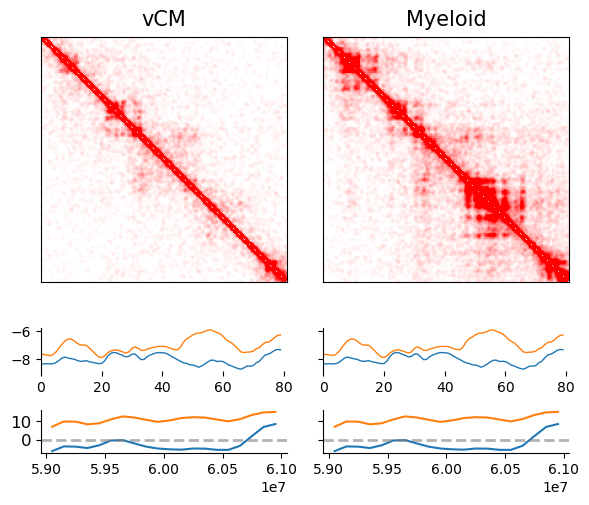

In [682]:
## Insulation score calculated on per celltype level is similar as we carried out on donor level
comp = pd.read_hdf('../04.matrices/comp/FNIH_heart_dhc_celltype_comp.impute.hdf')
comp[['chrom', 'start', 'end']] = comp.index.to_series().str.split('-', expand=True)
bbulk_ins = pd.read_csv('/projects/ps-renlab2/y2xie/projects/77.LC/87.FNIH_DHC_IGM_240925/impute/25K/domain/pseudobulk/FNIH_Heart_pseudobulk.insulation.csv', index_col = 0)

from itertools import repeat
from matplotlib.colors import LinearSegmentedColormap
colors = ["white", "red"]
custom_cmap = LinearSegmentedColormap.from_list("white_to_red", colors)

ipath = '../04.matrices/impute/cool/'
i = 11
chrom = f'chr{i}' 
binfilter = binpass[i-1]
res = 25_000
l, r = 59_000_000, 61_000_000 
ll = l//res
rr = r//res
boundl = chrom + "-" + str(l) + "-" + str(l+res)
boundr = chrom + "-" + str(r-res) + "-" + str(r)

korder = ['vCM', 'Myeloid']

fig, axes = plt.subplots(3, len(korder), figsize=(3*len(korder),5), 
                         gridspec_kw={'height_ratios':[3, 0.5, 0.5]}, sharey='row') ### , sharex='col'

for ind, ct in enumerate(korder):
    cool = cooler.Cooler(f'{ipath}/{ct}_10kb.cool::/')
    Q = cool.matrix(balance=False, sparse=True).fetch((chrom, l, r)).toarray()
    Q = Q - np.diag(np.diag(Q))
    
    ax = axes[0, ind]
    vv = 0.0008
    im = ax.imshow(Q, cmap = custom_cmap, vmax = vv) ### 10kb
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(ct, fontsize = 15, y = 1.01)
    
    ax = axes[1, ind]
    sns.despine(bottom=True, ax=ax)
    ax.plot(np.arange(rr - ll), np.log2(bbulk_ins.loc[boundl:boundr][korder]), linewidth=1)
    ax.set_xlim([0, rr - ll + 1]) ### 25kb
    plt.subplots_adjust(hspace=0.2)
    
    ax = axes[2, ind]
    subcomp1 = comp[comp["chrom"] == chrom]
    subcomp1['start'] = subcomp1['start'].astype(int)
    subcomp1['end'] = subcomp1['end'].astype(int)
    gvalue = subcomp1.loc[(subcomp1['start'] >= l) & (subcomp1['end'] <= r)]
    ax.plot(gvalue[['start', 'end']].mean(axis=1), gvalue[korder].values)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.tick_params(axis='y', labelsize=12)
    ax.axhline(y=0, color='grey', alpha = 0.6, linestyle='--', linewidth=2)
#     ax.xaxis.set_major_locator(ticker.MultipleLocator(36))
#     range_values = np.arange((l/1000000)-1, (r/1000000)+1, 1) ### 5, 5 breaks?
#     range_values_with_m = [f"{value}M" for value in range_values]
#     ax.xaxis.set_major_formatter(ticker.FixedFormatter(range_values))
    
plt.tight_layout()
plt.savefig(f'plot/FIG_vCM_Myeloid_{chrom}_{ll}_{rr}_impute.pdf', transparent = True)

## Pileup using boundaries calculated on pseudobulk level

In [33]:
import cooler
import bioframe
import cooltools

hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens = bioframe.fetch_centromeres('hg38')
hg38_arms = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)

resolution = 25_000
clr = cooler.Cooler(f'../04.matrices/FNIH_heart_dhc.mcool::resolutions/{resolution}')
hg38_arms = hg38_arms.set_index("chrom").loc[clr.chromnames].reset_index()

In [9]:
## Boundaries calculated on per celltype level is similar as we carried out on donor level
bound = anndata.read_h5ad("../impute/25K/domain/pseudobulk/FNIH_Heart_pseudobulk.boundary.h5ad")
bound

AnnData object with n_obs × n_vars = 36 × 123541
    var: 'chrom', 'start', 'end'

In [62]:
ct = 'vCM'
idx = np.where(bound.obs_names == ct)[0][0]
qbound = bound.var.iloc[nir[idx]]

clr = cooler.Cooler(f'../04.matrices/raw/cool/{ct}.mcool::resolutions/{resolution}')
expected = cooltools.expected_cis(clr, view_df=hg38_arms, nproc=2, chunksize=1_000_000)
stack = cooltools.pileup(clr, qbound, view_df=hg38_arms, expected_df=expected, flank=1_000_000)

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/expected.py:327: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:933: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features_df["region_offset"] = features_df["region"].replace(region_offsets_dict)
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positi

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:579: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:579: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:579: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

/tmp/ipykernel_979315/4246997367.py:1: RuntimeWarning: Mean of empty slice
  mtx = np.nanmean(stack, axis=0)


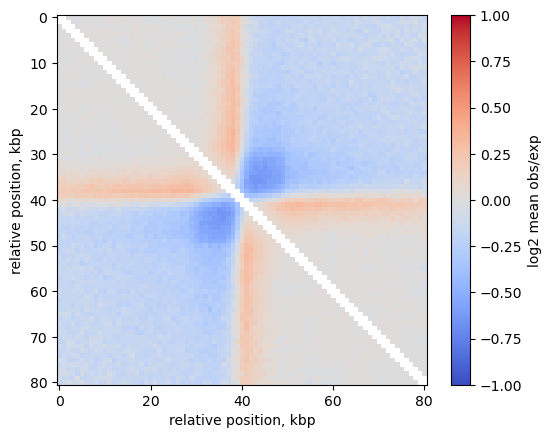

In [64]:
mtx = np.nanmean(stack, axis=0)
plt.imshow(
    np.log2(mtx),
    vmax = 1.0,
    vmin = -1.0,
    cmap='coolwarm',
    interpolation='none')

plt.colorbar(label = 'log2 mean obs/exp')
plt.xlabel('relative position, kbp')
plt.ylabel('relative position, kbp')

plt.show()

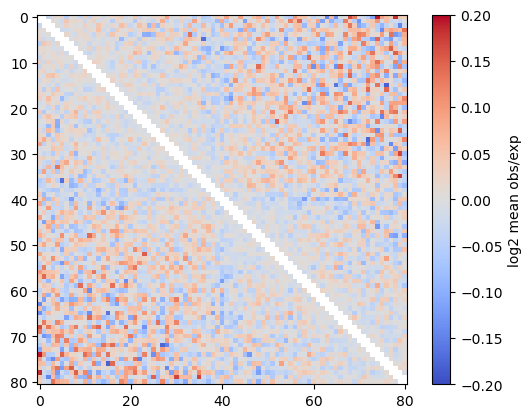

In [74]:
### HF / CTR
plt.imshow(
        np.log2(mtx[1]/mtx[0]),
        vmax = 0.2,
        vmin = -0.2,
        cmap='coolwarm',
        interpolation='none')

plt.colorbar(label = 'log2 mean obs/exp')

### Also check fib and myeloid

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/expected.py:327: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:933: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features_df["region_offset"] = features_df["region"].replace(region_offsets_dict)
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positi

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:579: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:579: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:579: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:675: RuntimeWarning: invalid value encountered in divide
  return snippet / e
/tmp/ipykernel_979315/1509965490.py:11: RuntimeWarning: Mean of empty slice
  mtx.append(np.nanmean(stack, axis=0))
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/expected.py:327: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:933: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.se

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:579: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:579: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:579: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:579: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

/tmp/ipykernel_979315/1509965490.py:11: RuntimeWarning: Mean of empty slice
  mtx.append(np.nanmean(stack, axis=0))


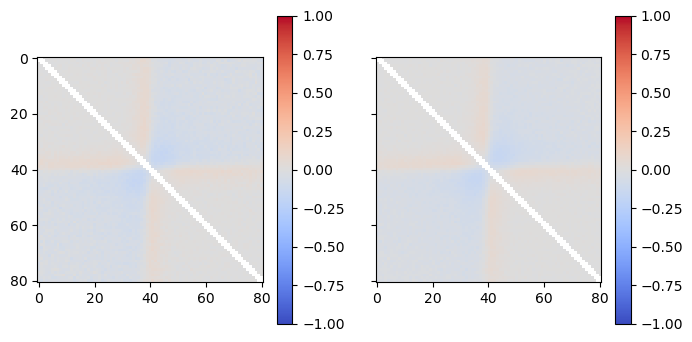

In [93]:
ct = 'Myeloid'
groups = [f'{ct}_CONTROL', f'{ct}_HF']
n_groups = len(groups)
mtx = []
fig, axs = plt.subplots(1, n_groups, sharex=True, sharey=True, figsize=(4*n_groups, 4))
for i in range(n_groups):
    clr = cooler.Cooler(f'../04.matrices/raw/cool/{groups[i]}.mcool::resolutions/{resolution}')
    expected = cooltools.expected_cis(clr, view_df=hg38_arms, nproc=2, chunksize=1_000_000)
    stack = cooltools.pileup(clr, qbound, view_df=hg38_arms, expected_df=expected, flank=1_000_000)
    mtx.append(np.nanmean(stack, axis=0))
    ax = axs[i]
    im = ax.imshow(np.log10(mtx[i]),
                   vmax = 1,
                   vmin = -1,
                   cmap='coolwarm',
                   interpolation='none')
    plt.colorbar(im, ax=ax)

plt.show()

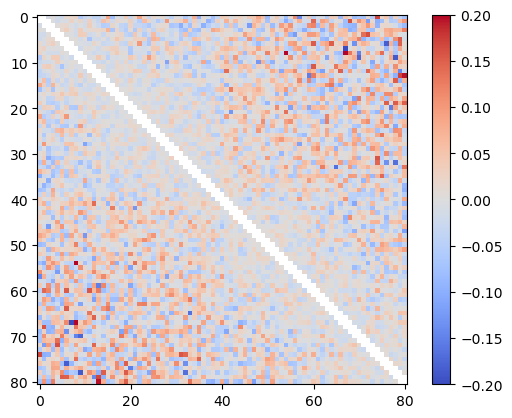

In [94]:
plt.imshow(
        np.log2(mtx[1]/mtx[0]),
        vmax = 0.2,
        vmin = -0.2,
        cmap='coolwarm',
        interpolation='none')

plt.colorbar()

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/expected.py:327: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:933: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features_df["region_offset"] = features_df["region"].replace(region_offsets_dict)
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positi

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:579: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:579: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:579: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:675: RuntimeWarning: invalid value encountered in divide
  return snippet / e
/tmp/ipykernel_979315/1359345188.py:13: RuntimeWarning: Mean of empty slice
  mtx.append(np.nanmean(stack, axis=0))
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/expected.py:327: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:933: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.se

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:579: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:579: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:579: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/home/y2xie/miniconda3/envs/seurat/lib/python3.11/site-packages/cooltools/api/snipping.py:576: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

/tmp/ipykernel_979315/1359345188.py:13: RuntimeWarning: Mean of empty slice
  mtx.append(np.nanmean(stack, axis=0))
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 15 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'eight', 'five', 'four', 'minus', 'nonmarkingreturn', 'one', 'period', 'seven', 'six', 'space', 'three', 'two', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 3228]
INFO:fontTools.subset:Closed glyph list over 'MATH': 15 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'eight', 'five', 'four', 'minus', 'nonmarking

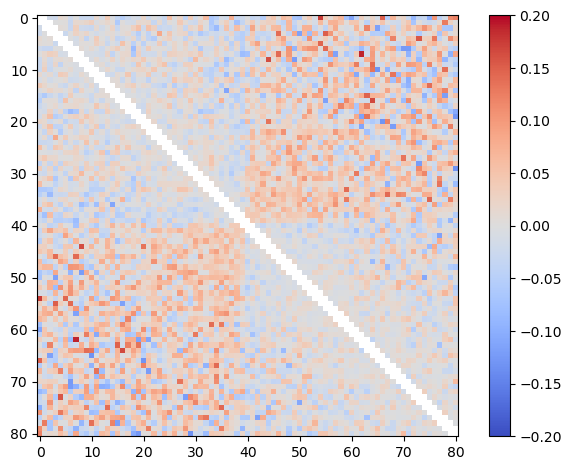

In [121]:
ct = 'Fibroblast'
idx = np.where(bound.obs_names == ct)[0][0]
qbound = bound.var.iloc[nir[idx]]

groups = [f'{ct}_CONTROL', f'{ct}_HF']
n_groups = len(groups)
mtx = []
for i in range(n_groups):
    clr = cooler.Cooler(f'../04.matrices/raw/cool/young/{groups[i]}.mcool::resolutions/25000')
    expected = cooltools.expected_cis(clr, view_df=hg38_arms, nproc=2, chunksize=1_000_000)
    stack = cooltools.pileup(clr, qbound, view_df=hg38_arms, expected_df=expected, flank=1_000_000)
    mtx.append(np.nanmean(stack, axis=0))
    
plt.imshow(
        np.log2(mtx[1]/mtx[0]),
        vmax = 0.2,
        vmin = -0.2,
        cmap='coolwarm',
        interpolation='none')

plt.colorbar()
plt.tight_layout()
plt.savefig(f'plot/FIG_bound_pileup_HF_vs_CONTROL_{ct}_by_donor.pdf')